# Landweber iteration and discrepancy principle
In this lab, you should solve a three-dimensional tomography problem with the Landweber method. Have a look at the lecture slides to see how this method should work. 

* Start by initializing an appropriate discretized space, in this case a three-dimensional function space centered at (0,0,0), starting with $32 \times 32 \times 32$ resolution for testing. Pass ``dtype='float32'``, which the ASTRA backend requires in ODL 1.0.

* Create a three-dimensional [Shepp–Logan phantom](https://odl.readthedocs.io/generated/odl.core.phantom.transmission.shepp_logan.html) in the space by calling ``odl.phantom.transmission.shepp_logan(Space, modified=True)`` (noting that the modified phantom has much higher contrast than the unmodified version). Make sure that the phantom is centered at the origin with the ``show`` method (this only shows a slice of this 3D function). 

* Form the forward operator for the ray transform with a [cone beam geometry](https://odl.readthedocs.io/generated/odl.applications.tomo.geometry.conebeam.cone_beam_geometry.html) (you can call ``odl.applications.tomo.cone_beam_geometry``) with a small number $(\sim 10)$ of angles, otherwise you will not see the effects of semi-convergence. 

* Apply the forward operator to the phantom to obtain the sinogram, then add some noise to it (note that the sinogram lives in ``Operator.range``).

* You can obtain the norm of a vector with its [norm method](https://odl.readthedocs.io/generated/odl.DiscretizedSpaceElement.norm.html). For the discrepancy of the Landweber method, you will also need the absolute noise level $\| g - g_{\mathrm{noisy}}\|$ of the sinogram $g$ (in real applications you must estimate the noise level somehow).

* You can obtain an estimate of the largest singular value of the forward operator with its [norm method](https://odl.readthedocs.io/generated/odl.Operator.norm.html). Note that this is operator norm, which may need to be estimated (by odl) if the relevant space does not have an analytic method for calculating it.

* The adjoint of the forward operator is given by ``Operator.adjoint``.

* Implement the Landweber method as a function and employ $\sim 200$ iterations to obtain a solution for the noisy sinogram, starting with the [zero vector](https://odl.readthedocs.io/generated/odl.DiscretizedSpace.zero.html) as your initial guess.

* Log the pertinent norms between iterations and check when the discrepancy criterion is satisfied (but do not stop the iteration).

* Plot the relative error of your reconstructions against the number of iterations and check when the discrepancy criterion would have stopped the iterations: what would it have given you?

* Use the ``show`` method to inspect your best reconstruction and compare it with the original phantom. Since this is a 3D function, you should also try to show different slices and perspectives (check the documentation for details).

In [1]:
!nvidia-smi

Tue Sep 29 08:49:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P0             28W /   70W |     107MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!rm -rf InverseProblems-Labs
!git clone https://github.com/AhouLucas/InverseProblems-Labs.git
%cd InverseProblems-Labs
!uv sync
!uv pip install --system astra-toolbox

Cloning into 'InverseProblems-Labs'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 62 (delta 28), reused 25 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 1.37 MiB | 15.24 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/InverseProblems-Labs
Using CPython 3.12.3 interpreter at: /usr/bin/python3.12
Creating virtual environment at: .venv
Resolved 73 packages in 10ms
Prepared 58 packages in 5.09s                                            
Installed 61 packages in 309ms                              
 + annotated-doc==0.0.5
 + array-api-compat==1.15.0
 + asttokens==3.0.2
 + certifi==2026.7.22
 + charset-normalizer==3.5.1
 + comm==0.2.3
 + contourpy==1.3.3
 + coverage==7.15.4
 + coveralls==4.1.0
 + cycler==0.12.1
 + debugpy==1.8.21
 + executing==2.2.1
 + fonttools==4.63.0
 + future==1.0.0
 + idna==3.19
 + iniconfig==2.3.0
 + ipykernel==7.3.0
 + ipython==9.16

In [3]:
import odl
import numpy as np
import matplotlib.pyplot as plt

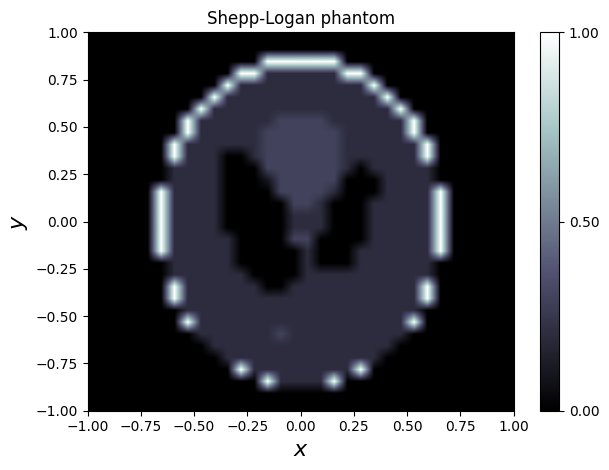

<Figure size 640x480 with 0 Axes>

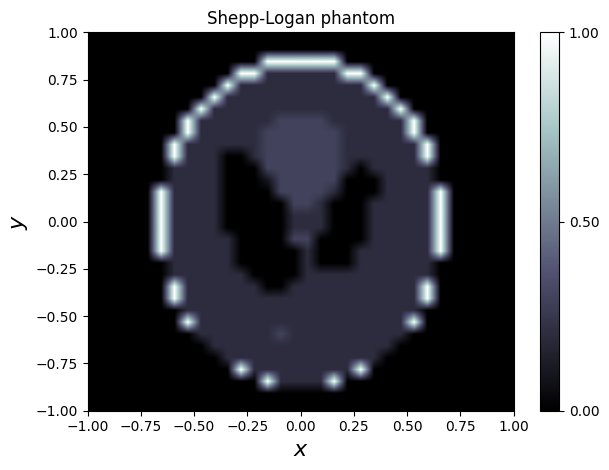

In [4]:
space = odl.uniform_discr((-1, -1, -1), (1, 1, 1), (32, 32, 32), dtype='float32')

shepp_logan = odl.phantom.transmission.shepp_logan(space, modified=True)
shepp_logan.show(title='Shepp-Logan phantom')

In [5]:
import sys
print(sys.executable)

try:
    import astra
    print("astra version:", astra.__version__)
    print("CUDA available:", astra.use_cuda())
except Exception as e:
    print("astra import failed:", repr(e))

/usr/bin/python3
astra version: 2.5.0
CUDA available: True


Noise level (L2 norm): 0.0690


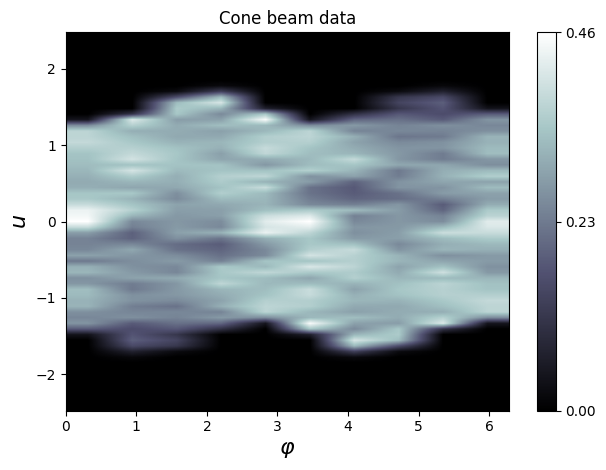

<Figure size 640x480 with 0 Axes>

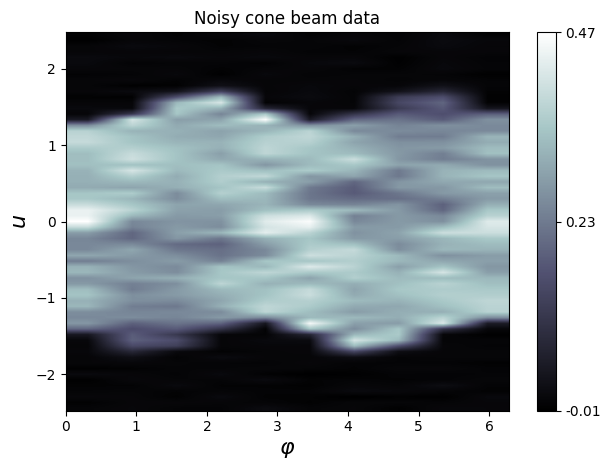

<Figure size 640x480 with 0 Axes>

In [6]:
cone_beam_geo = odl.applications.tomo.cone_beam_geometry(space, src_radius=2.0, det_radius=1.5, num_angles=10)
ray_transform = odl.applications.tomo.RayTransform(space, cone_beam_geo, impl='astra_cuda')
ray_transform_elements = ray_transform(shepp_logan)
noisy_elements = ray_transform_elements + odl.phantom.white_noise(ray_transform.range, stddev=0.005)

# Compute noise level
error = noisy_elements - ray_transform_elements
noise_level = error.norm()
print(f"Noise level (L2 norm): {noise_level:.4f}")

fig_ray_transform_elements = ray_transform(shepp_logan).show(title='Cone beam data')
fig_noisy_elements = noisy_elements.show(title='Noisy cone beam data')

In [7]:
# Landweber iteration

def landweber_iteration(A, y, iterations=200, noise_level=None, morozov_constant=1.0):
    # Compute largest singular value of A to choose step size
    # Cast to a Python float: a NumPy scalar on the left of `*` would try to
    # convert the ODL element to an array, which ODL 1.0 forbids
    sigma = float(A.norm(estimate=True))
    omega = 1 / sigma**2

    # Initialize x to zero in the domain of A
    x = A.domain.zero()
    x_best = x.copy()
    residual_best = float('inf')

    # Log pertinent information
    logs = {
        "residuals": [],
        "morozov_stop_iteration": -1,
        "x_best": x_best,
        "residual_best": residual_best
    }

    for _ in range(iterations):
        if noise_level is not None and logs["morozov_stop_iteration"] == -1 and logs["residuals"] and logs["residuals"][-1] <= morozov_constant * noise_level:
            logs["morozov_stop_iteration"] = len(logs["residuals"])
        logs["residuals"].append((A(x) - y).norm())
        if logs["residuals"][-1] < residual_best:
            x_best = x.copy()
            residual_best = logs["residuals"][-1]
            logs["x_best"] = x_best
            logs["residual_best"] = residual_best
        x = x + omega * A.adjoint(y - A(x))
    return x, logs

In [12]:
# Perform Landweber iteration
reconstructed_image, logs = landweber_iteration(ray_transform, noisy_elements, iterations=200, noise_level=noise_level, morozov_constant=1.2)

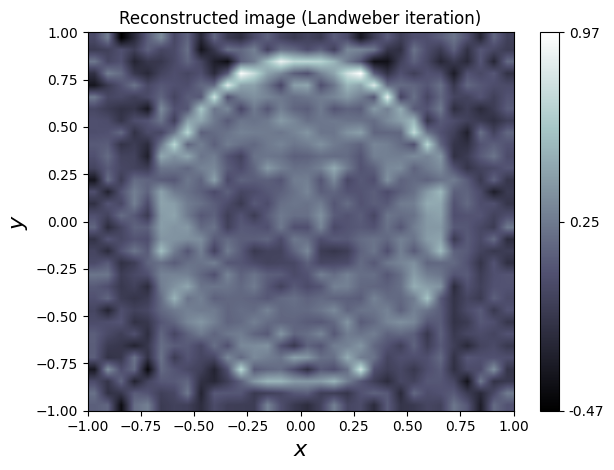

<Figure size 640x480 with 0 Axes>

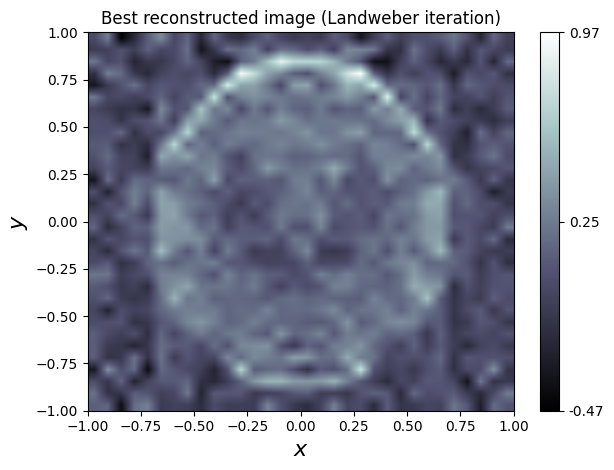

<Figure size 640x480 with 0 Axes>

Minimum residual: 0.0747 at iteration 199
Morozov residual: 0.0825 at iteration 94


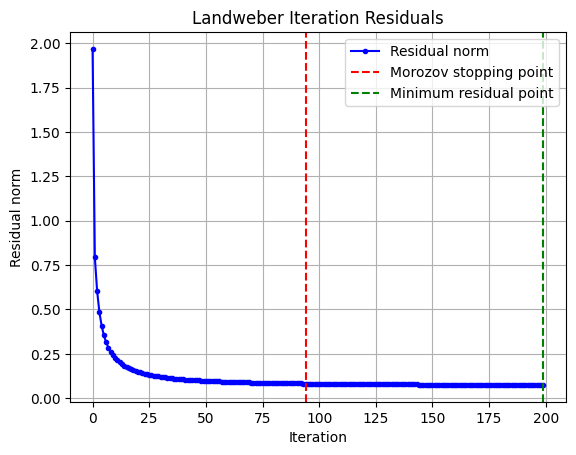

In [13]:
# Plot the reconstructed image and the residuals
fig_reconstructed_image = reconstructed_image.show(title='Reconstructed image (Landweber iteration)')
fig_best_reconstructed_image = logs["x_best"].show(title='Best reconstructed image (Landweber iteration)')

# Find minimum residual and its corresponding iteration
min_residual = min(logs["residuals"])
min_residual_iteration = logs["residuals"].index(min_residual)
print(f"Minimum residual: {min_residual:.4f} at iteration {min_residual_iteration}")
print(f"Morozov residual: {logs["residuals"][logs['morozov_stop_iteration']]:.4f} at iteration {logs['morozov_stop_iteration']}")

plt.figure()
plt.plot(logs["residuals"], label='Residual norm', marker='.', color='b')
if logs["morozov_stop_iteration"] != -1:
    plt.axvline(logs["morozov_stop_iteration"], color='r', linestyle='--', label='Morozov stopping point')
plt.axvline(min_residual_iteration, color='g', linestyle='--', label='Minimum residual point')
plt.xlabel('Iteration')
plt.ylabel('Residual norm')
plt.title('Landweber Iteration Residuals')
plt.legend()
plt.grid()
plt.show()